<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Chapter05_02_%EC%BA%90%EA%B8%80%EC%A3%BC%ED%83%9D%EA%B0%80%EA%B2%A9_%ED%9A%8C%EA%B7%80%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (1).ttf


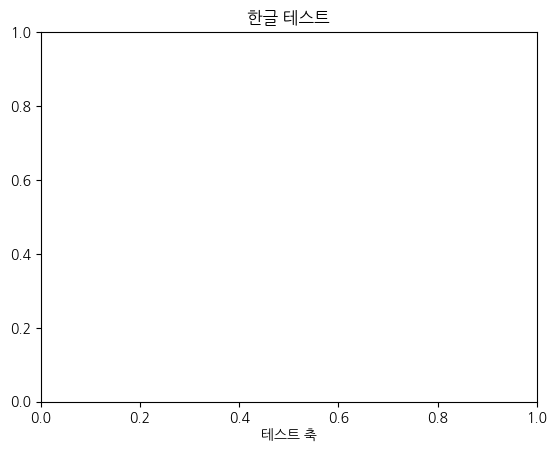

In [60]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor # XGBoost 회귀용 클래스
from lightgbm import LGBMRegressor # LightGBM 회귀용 클래스

In [62]:
# 데이터 로딩 및 기본 탐색(EDA)

# 캐글 House Prices 데이터셋, 미국 아이오와주 애임스(Ames) 지역 주택 거래 데이터
house_df_org = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/house_prices/train.csv')
house_df     = house_df_org.copy()

print('데이터 크기:', house_df.shape) # Id + 79개 피처 + SalePrice
print('\n피처 타입 분포:')
print(house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print('\n결측치 많은 컬럼 (상위 10개):') #결측 80% 이상 -> 삭제 예정
print(isnull_series[isnull_series > 0].sort_values(ascending=False).head(10))
house_df.head(3)

데이터 크기: (1460, 81)

피처 타입 분포:
object     43
int64      35
float64     3
Name: count, dtype: int64

결측치 많은 컬럼 (상위 10개):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


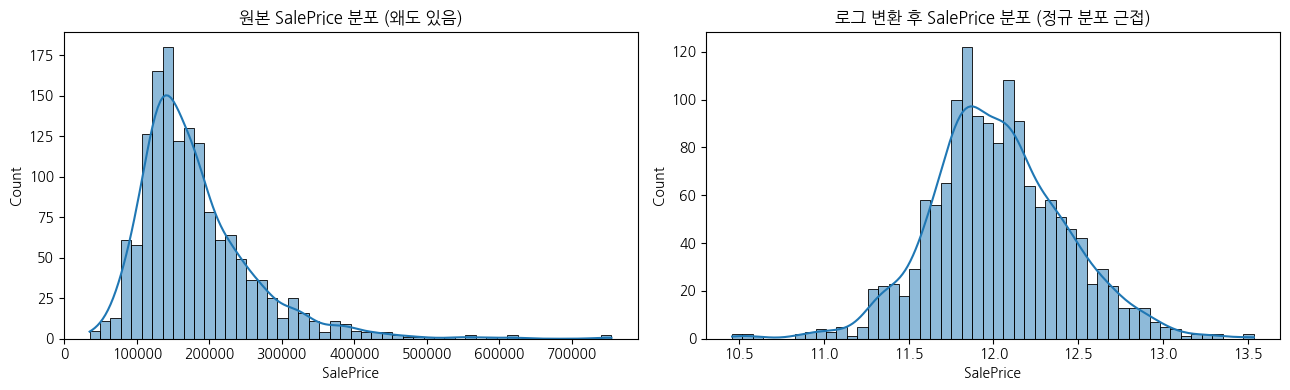

In [63]:
# SalePrice 분포 확인 및 로그 변환 필요성 검토
# 선형 회귀는 종속변수(SalePrice)가 정규 분포에 가까울수록 성능 좋음
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].set_title('원본 SalePrice 분포 (왜도 있음)')
sns.histplot(house_df['SalePrice'], bins=50, kde=True, ax=axes[0])

axes[1].set_title('로그 변환 후 SalePrice 분포 (정규 분포 근접)')
sns.histplot(np.log1p(house_df['SalePrice']), bins=50, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [64]:
# STEP 1: 전처리 - 로그 변환 + 결측치 처리 + 원-핫 인코딩
# [전처리 순서가 중요한 이유]
# 1. SalePrice 로그 변환 (모델 가정 충족)
# 2. 결측치 처리 (모델이 NaN을 처리 못함)
# 3. 원-핫 인코딩 (문자형을 수치형으로 변환)

house_df['SalePrice'] = np.log1p(house_df['SalePrice'])
house_df.drop(
    ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'],
    axis=1, inplace=True, errors='ignore'
)
numeric_cols = house_df.select_dtypes(include=np.number).columns
house_df[numeric_cols] = house_df[numeric_cols].fillna(house_df[numeric_cols].mean())#각 컬럼별로 평균값이 결측치로 대체

null_cols = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('남은 결측 컬럼 타입:\n', house_df.dtypes[null_cols.index])

남은 결측 컬럼 타입:
 MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
dtype: object


In [65]:
# Step 2: 원-핫 인코딩(One-Hot Encoding)
# pd.get_dummies vs sklearn OneHotEncoder
# get_dummies는 결측값(NaN)을 0으로 처리, 전체 데이터를 한 번에 변환, 학습/테스트 분리 후 컬럼 수 불일치 주의
print('get_dummies() 전 shape:', house_df.shape)

house_df_ohe = pd.get_dummies(house_df)
print('get_dummies() 후 shape:', house_df_ohe.shape)
null_cols = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum() > 0]
print(len(null_cols))

get_dummies() 전 shape: (1460, 75)
get_dummies() 후 shape: (1460, 270)
0


In [66]:
# 선형 회귀 모델 학습/예측/평가

# 학습/테스트 분리
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)
print('학습셋:', X_train.shape, '테스트셋:', X_test.shape)

학습셋: (1168, 269) 테스트셋: (292, 269)


In [67]:
def get_rmse(model):
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  print(f'{model.__class__.__name__} 로그 변환돤 RMSE: {rmse:.3f}')
  return rmse

def get_rmses(models):
  return [get_rmse(model) for model in models]

In [68]:
#LinearRegression / Ridge / Lasso 기본 학습
lr_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()

lr_reg.fit(X_train, y_train)
ridge_reg.fit(X_train, y_train)
lasso_reg.fit(X_train, y_train)

print('기본 하이퍼파라미터 RMSE')
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

기본 하이퍼파라미터 RMSE
LinearRegression 로그 변환돤 RMSE: 0.132
Ridge 로그 변환돤 RMSE: 0.127
Lasso 로그 변환돤 RMSE: 0.176


[np.float64(0.13183184688250701),
 np.float64(0.1274058283626616),
 np.float64(0.17628250556471403)]

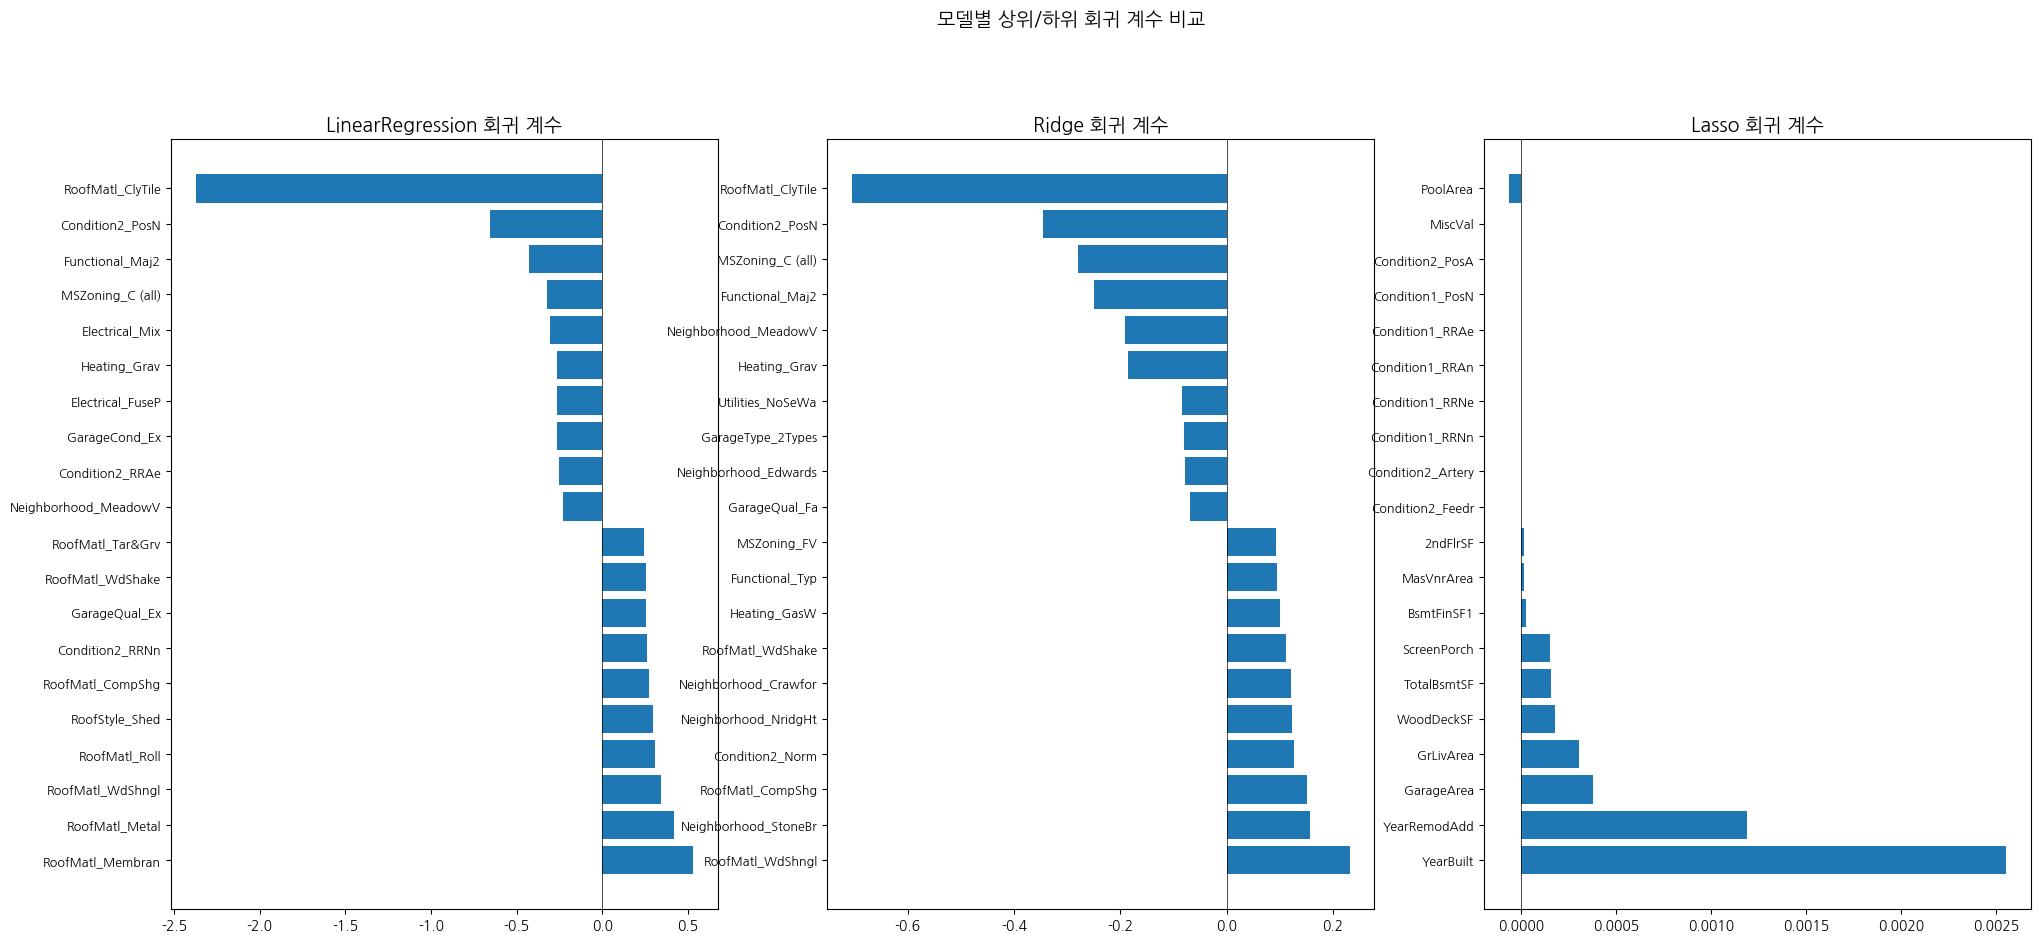

In [69]:
# 상위 10개(양의 영향) / 하위 10개(음의 영향) 회귀 계수 추출
def get_top_bottom_coef(model):
  coef = pd.Series(model.coef_, index=X_features.columns) # model.coef_: 각 피처의 회귀 계수 (양수=가격 상승, 음수=가격 하락)
  coef_high = coef.sort_values(ascending=False).head(10)
  coef_low = coef.sort_values(ascending=False).tail(10)
  return coef_high, coef_low

# 회귀 계수 시각화 함수
def visualize_coefficient(models):
  fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=3)
  for i, model in enumerate(models):
    coef_high, coef_low = get_top_bottom_coef(model)
    coef_concat = pd.concat([coef_high, coef_low]) # 하나의 Series로 합침
    axs[i].set_title(f'{model.__class__.__name__} 회귀 계수', size=14)
    axs[i].tick_params(axis='y', labelsize=9)
    axs[i].barh(coef_concat.index, coef_concat.values)
    axs[i].axvline(0, color='black', linewidth=0.5)
  plt.suptitle('모델별 상위/하위 회귀 계수 비교', fontsize=14, y=1.01)
  fig.tight_layout
  plt.show()

visualize_coefficient(models)

In [70]:
# 5-Fold 교차 검증 RMSE 비교
def get_avg_rmse_cv(models):
  for model in models:
    rmse_list = np.sqrt(-cross_val_score(
        model, X_features, y_target,
        scoring='neg_mean_squared_error',
        cv=5))
    print(f'{model.__class__.__name__} CV RMSE: {np.round(rmse_list, 3)} 평균: {np.round(np.mean(rmse_list), 3)}')

print('5-Fold 교차 검증 RMSE')
get_avg_rmse_cv([lr_reg, ridge_reg, lasso_reg])
# 5개 폴드 RMSE가 비슷하면 안정적, 차이가 크면 불안정한 모델

5-Fold 교차 검증 RMSE
LinearRegression CV RMSE: [0.135 0.165 0.167 0.111 0.198] 평균: 0.155
Ridge CV RMSE: [0.117 0.154 0.142 0.117 0.189] 평균: 0.144
Lasso CV RMSE: [0.161 0.204 0.177 0.181 0.265] 평균: 0.198


In [71]:
# GridSearchCV로 최적 alpha 탐색
ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]} # L1규제는 계수를 0으로 만드는 힘 강함

def print_best_params(model, params):
  grid_model = GridSearchCV(
      model, param_grid=params,
      scoring='neg_mean_squared_error', cv=5
  )
  grid_model.fit(X_features, y_target)
  rmse = np.sqrt(-1 * grid_model.best_score_)
  print(f'{model.__class__.__name__} 5-CV 최적 RMSE: {rmse:.4f} 최적 하이퍼 파라미터: {grid_model.best_params_}')
  return grid_model.best_estimator_ # 최적 파라미터로 학습된 모델 반환

best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.1418 최적 하이퍼 파라미터: {'alpha': 12}
Lasso 5-CV 최적 RMSE: 0.1420 최적 하이퍼 파라미터: {'alpha': 0.001}


[최적 alpha 적용 후] RMSE
LinearRegression 로그 변환돤 RMSE: 0.132
Ridge 로그 변환돤 RMSE: 0.124
Lasso 로그 변환돤 RMSE: 0.120


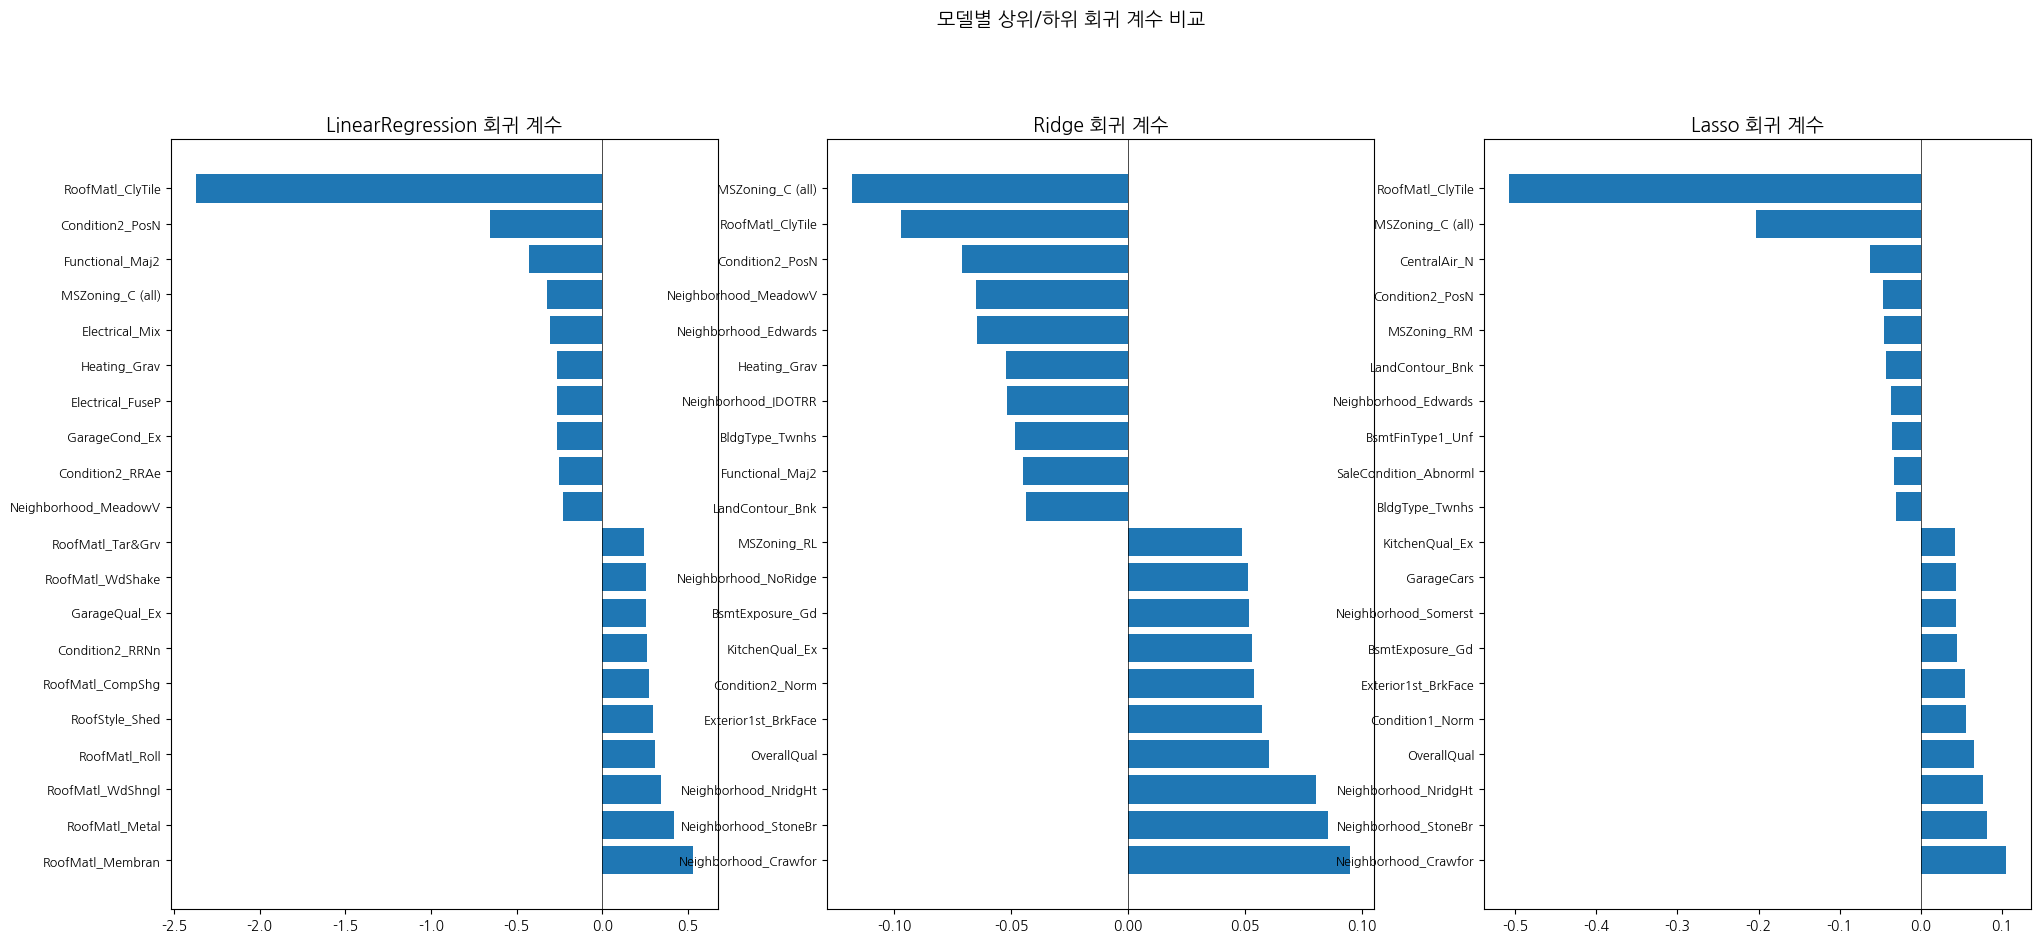

In [72]:
# 최적 alpha로 재학습 및 성능 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=12)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
    model.fit(X_train, y_train)

print('[최적 alpha 적용 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg])

In [73]:
# 수치형 피처의 왜도(Skewness) 분석
features_index = house_df.dtypes[house_df.dtypes != 'object'].index # 수치형 컬럼만 선택
skew_features = house_df[features_index].apply(lambda x: skew(x)) # 각 수치형 컬럼에 .skew() 적용
skew_features_top = skew_features[skew_features > 1] ## 왜도 1 이상인 피처만 필터링
print('왜도 > 1인 피처 목록 (내림차순):')
print(skew_features_top.sort_values(ascending=False))

왜도 > 1인 피처 목록 (내림차순):
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [74]:
# 왜도 높은 피처 로그 변환 후 전체 파이프라인 재실행
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])
house_df_ohe = pd.get_dummies(house_df) # 로그 변환 후 원-핫 인코딩 재적용
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)

# 왜도 처리 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.1275 최적 하이퍼 파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.1252 최적 하이퍼 파라미터: {'alpha': 0.001}


[왜도 처리 후] RMSE
LinearRegression 로그 변환돤 RMSE: 0.128
Ridge 로그 변환돤 RMSE: 0.122
Lasso 로그 변환돤 RMSE: 0.119


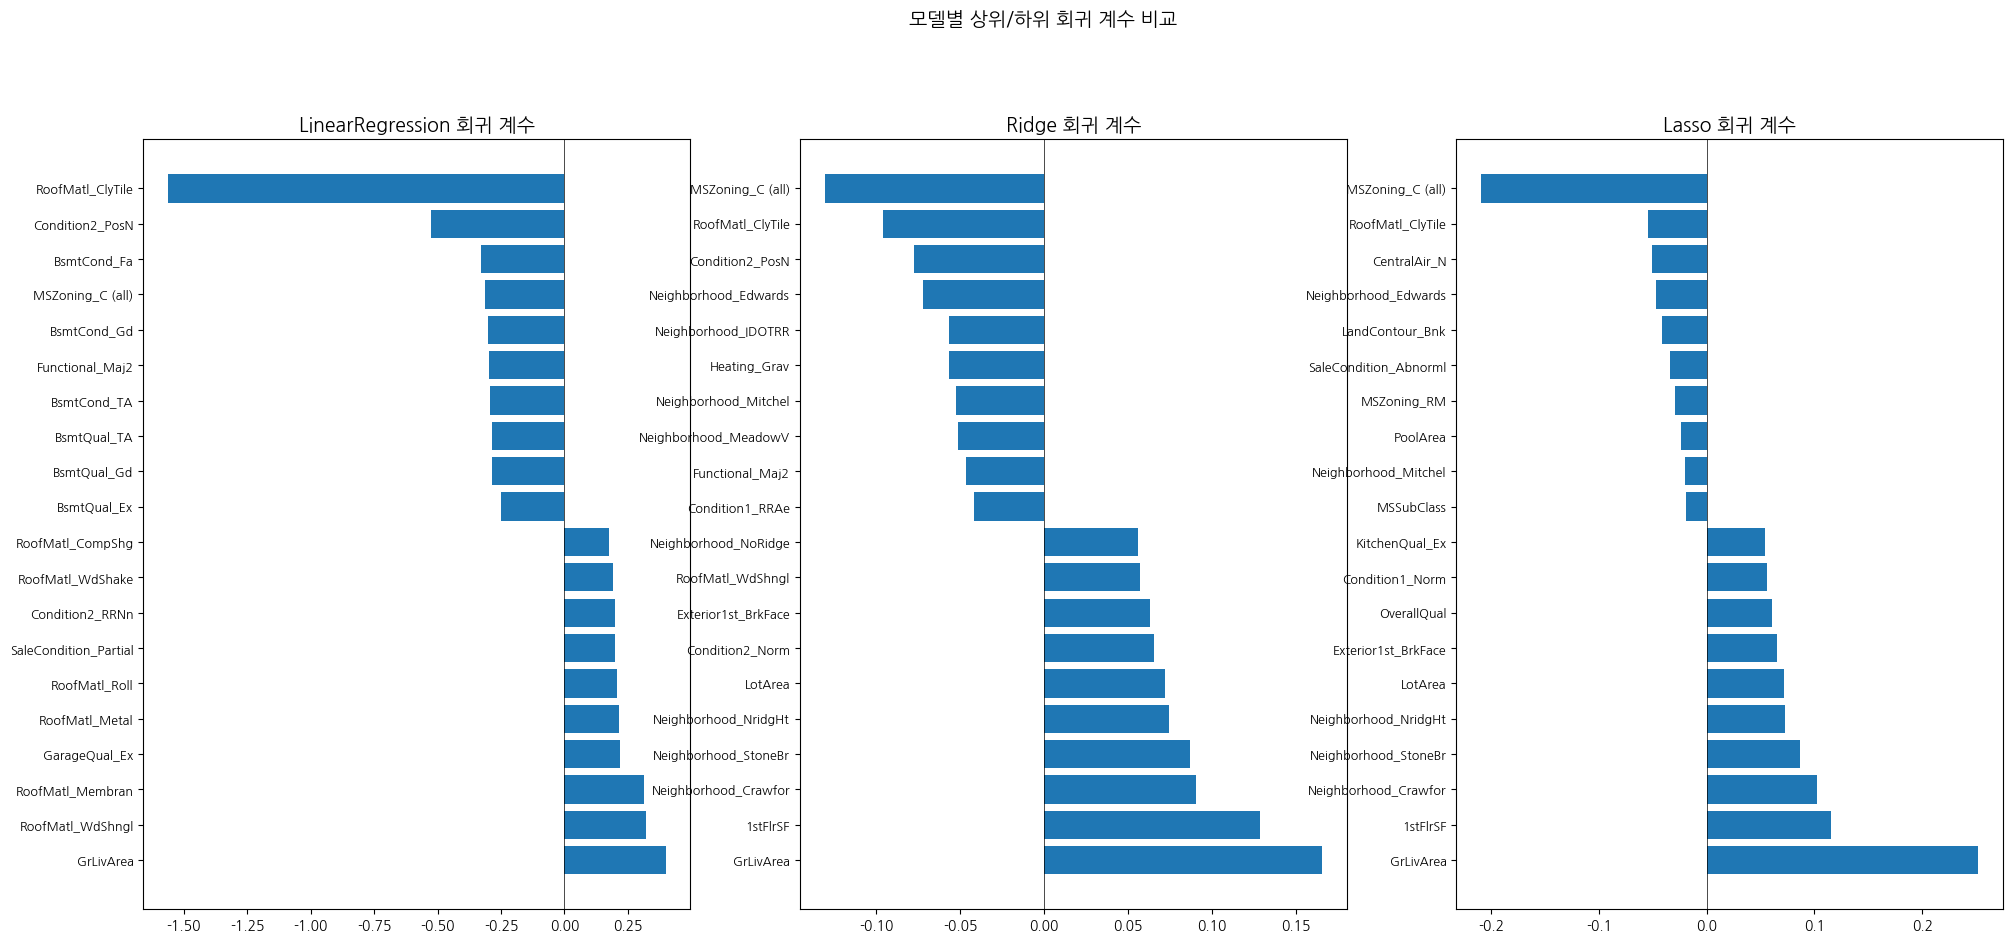

In [75]:
# 왜도 처리 후 최적 하이퍼 파라미터로 재학습 및 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
    model.fit(X_train, y_train)

print('[왜도 처리 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg])

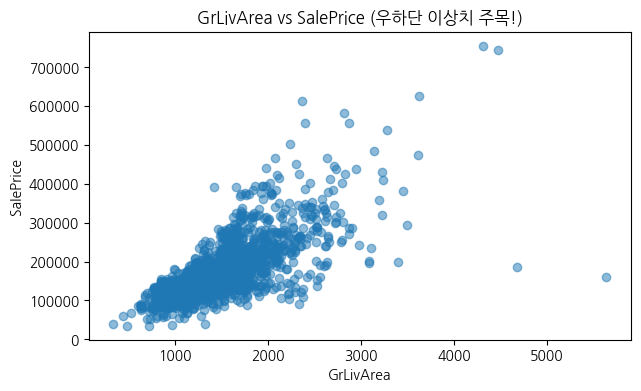

In [76]:
# 이상치(Outlier) 탐지: GrLivArea vs SalePrice 산점도
# 선형 회귀는 최소제곱법(MSE 최소화) -> 이상치에 민감, 이상치 하나가 회귀선 전체를 왜곡 가능
plt.figure(figsize=(7, 4))
plt.scatter(
    x=house_df_org['GrLivArea'],
    y=house_df_org['SalePrice'],
    alpha=0.5
)
plt.ylabel('SalePrice')
plt.xlabel('GrLivArea')
plt.title('GrLivArea vs SalePrice (우하단 이상치 주목!)')
plt.show()

In [79]:
# 이상치 제거
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(500000)
outlier_index = house_df_ohe[cond1 & cond2].index

print('이상치 레코드 인덱스:', outlier_index.values)
print('이상치 삭제 전:', house_df_ohe.shape)
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후:', house_df_ohe.shape)

이상치 레코드 인덱스: []
이상치 삭제 전: (1458, 270)
이상치 삭제 후: (1458, 270)


Ridge 5-CV 최적 RMSE: 0.1125 최적 하이퍼 파라미터: {'alpha': 8}
Lasso 5-CV 최적 RMSE: 0.1122 최적 하이퍼 파라미터: {'alpha': 0.001}
[왜도 처리 후] RMSE
LinearRegression 로그 변환돤 RMSE: 0.129
Ridge 로그 변환돤 RMSE: 0.103
Lasso 로그 변환돤 RMSE: 0.100


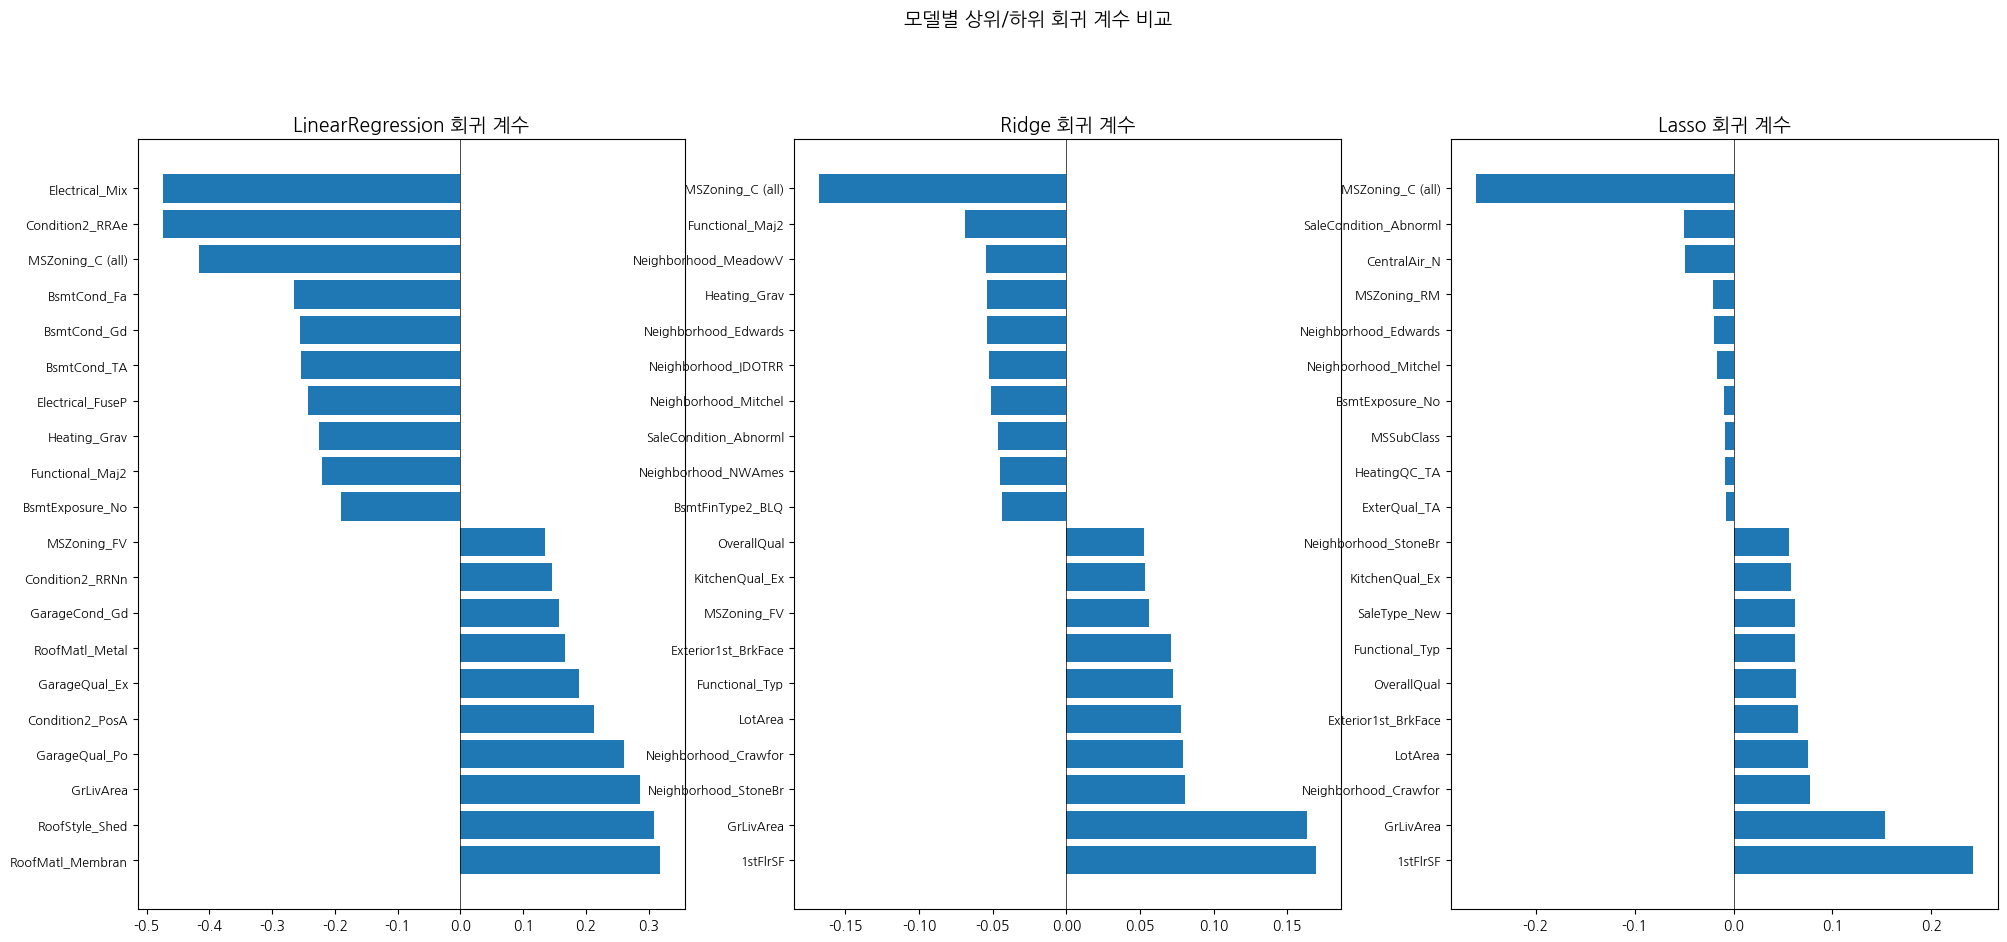

In [78]:
# 이상치 제거 후 재분리 + 최종 선형 모델 평가

# 학습/테스트 분리 (동일 random_state로 공정 비교)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)
# 이상치 제거 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

# 이상치 제거 후 최적 하이퍼 파라미터로 최종 선형 모델 학습
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=8)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
    model.fit(X_train, y_train)

print('[왜도 처리 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg])